In [1]:
import optuna
import pandas as pd

# 1. Connessione al database
# study_name = 'my_cv_optimization_cadmus_02_02_26_HS'
# storage_path = 'sqlite:///my_study_cadmus_02_02_26_HS.db'
study_name='my_cv_optimization_cadmus_data1_RIPRODUCIBILE_03_02_26'  # Un nome per il tuo studio
storage_path='sqlite:///my_study_cadmus_data1_RIPRODUCIBILE_03_02_26.db'  # Nome del file dove salvare
study = optuna.load_study(study_name=study_name, storage=storage_path)

# 2. Estrazione di tutti i trial in un DataFrame
df = study.trials_dataframe()

# 3. Pulizia opzionale: rinominiamo le colonne per leggerle meglio
# Rimuove i prefissi 'user_attrs_' e 'params_' dai nomi delle colonne
df.columns = [c.replace('user_attrs_', '').replace('params_', '') for c in df.columns]

# 4. Ordinamento per il miglior risultato (MCC)
df = df.sort_values(by="value", ascending=False)

# # 5. Salvataggio in vari formati
# df.to_csv("estrazione_completa_optuna.csv", index=False)
# df.to_excel("estrazione_completa_optuna.xlsx", index=False) # Richiede openpyxl

print(f"Estrazione completata! Totale trial analizzati: {len(df)}")
print("\nPrime 5 righe (Migliori trial):")
df

Estrazione completata! Totale trial analizzati: 93

Prime 5 righe (Migliori trial):


,number,value,datetime_start,datetime_complete,duration,batch_size,dropout_rate,lr,num_heads,patience,...,test_mean_Sn,test_mean_Sp,test_std_ACC,test_std_AUROC,test_std_F1,test_std_MCC,test_std_PR_AUC,test_std_Sn,test_std_Sp,state
1,1,0.777878,2026-02-05 11:13:43.528066,2026-02-05 11:19:21.350820,0 days 00:05:37.822754,32,0.383229,0.000002,5,10,...,0.903643,0.864348,0.005703,0.004809,0.007084,0.011935,0.009470,0.017846,0.006679,COMPLETE
6,6,0.764070,2026-02-05 11:31:34.176567,2026-02-05 11:34:54.654414,0 days 00:03:20.477847,64,0.339160,0.000006,4,14,...,0.901891,0.860435,0.004313,0.003029,0.004856,0.008961,0.007482,0.011627,0.006929,COMPLETE
50,50,0.763360,2026-02-05 14:13:00.492931,2026-02-05 14:15:52.527372,0 days 00:02:52.034441,32,0.435117,0.000005,4,7,...,0.895292,0.871739,0.003644,0.004128,0.004020,0.007373,0.009600,0.015895,0.015616,COMPLETE
11,11,0.762547,2026-02-05 11:45:47.590790,2026-02-05 11:50:15.530875,0 days 00:04:27.940085,64,0.445974,0.000003,4,12,...,0.897928,0.865652,0.004898,0.005382,0.005992,0.010201,0.010873,0.017651,0.011939,COMPLETE
2,2,0.762192,2026-02-05 11:19:21.358576,2026-02-05 11:21:22.894063,0 days 00:02:01.535487,64,0.272778,0.000008,5,7,...,0.891337,0.868696,0.005434,0.004961,0.006782,0.011258,0.011300,0.019278,0.011388,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,3,0.722900,2026-02-05 11:21:22.901837,2026-02-05 11:23:39.425648,0 days 00:02:16.523811,32,0.305694,0.000079,8,13,...,0.881634,0.863478,0.012560,0.003563,0.017541,0.024756,0.005565,0.048191,0.022982,COMPLETE
47,47,0.720401,2026-02-05 14:04:24.278218,2026-02-05 14:05:34.587601,0 days 00:01:10.309383,64,0.327439,0.000017,4,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED
81,81,0.719115,2026-02-05 16:09:48.141739,2026-02-05 16:11:13.077562,0 days 00:01:24.935823,64,0.452717,0.000024,5,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED
8,8,0.714637,2026-02-05 11:36:36.771062,2026-02-05 11:38:21.207634,0 days 00:01:44.436572,32,0.102209,0.000005,4,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED


In [2]:
df.loc[1]

number                                           1
value                                     0.777878
datetime_start          2026-02-05 11:13:43.528066
datetime_complete       2026-02-05 11:19:21.350820
duration                    0 days 00:05:37.822754
batch_size                                      32
dropout_rate                              0.383229
lr                                        0.000002
num_heads                                        5
patience                                        10
weight_decay                                   0.0
internal_mean_ACC                         0.887432
internal_mean_AUROC                       0.936264
internal_mean_F1                          0.891092
internal_mean_MCC                         0.777878
internal_mean_PR_AUC                      0.924641
internal_mean_Sn                          0.925275
internal_mean_Sp                              0.85
internal_std_ACC                          0.017141
internal_std_AUROC             

In [180]:
df.sort_values(by='test_mean_MCC',ascending=False)['test_mean_MCC']#.loc[1]

13    0.769915
54    0.768971
29    0.768970
56    0.768791
1     0.768678
        ...   
5          NaN
35         NaN
47         NaN
8          NaN
69         NaN
Name: test_mean_MCC, Length: 70, dtype: float64

In [105]:
study.best_trial

FrozenTrial(number=19, state=TrialState.COMPLETE, values=[0.7667833801959223], datetime_start=datetime.datetime(2026, 2, 5, 3, 39, 47, 542697), datetime_complete=datetime.datetime(2026, 2, 5, 4, 54, 43, 444021), params={'dropout_rate': 0.38411351100743807, 'num_heads': 8, 'batch_size': 32, 'lr': 1.605446209951282e-06, 'weight_decay': 1.0734449314116993e-08, 'patience': 15}, user_attrs={'internal_mean_ACC': 0.881967213114754, 'internal_mean_AUROC': 0.9307931199235547, 'internal_mean_F1': 0.8851079615122739, 'internal_mean_MCC': 0.7667833801959223, 'internal_mean_PR_AUC': 0.916277981390109, 'internal_mean_Sn': 0.9164835164835164, 'internal_mean_Sp': 0.8478260869565218, 'internal_std_ACC': 0.01568601103213917, 'internal_std_AUROC': 0.014797513758200383, 'internal_std_F1': 0.016764191058266605, 'internal_std_MCC': 0.03235816774500631, 'internal_std_PR_AUC': 0.01923563101376485, 'internal_std_Sn': 0.03447118053045744, 'internal_std_Sp': 0.020623549957619874, 'test_mean_ACC': 0.5018579234972

In [141]:
df.loc[10]#['value']

number                                          10
value                                          NaN
datetime_start          2026-02-05 11:40:33.627008
datetime_complete                              NaT
duration                                       NaT
batch_size                                      32
dropout_rate                              0.487175
lr                                        0.000003
num_heads                                        5
patience                                        10
weight_decay                                   0.0
internal_mean_ACC                              NaN
internal_mean_AUROC                            NaN
internal_mean_F1                               NaN
internal_mean_MCC                              NaN
internal_mean_PR_AUC                           NaN
internal_mean_Sn                               NaN
internal_mean_Sp                               NaN
internal_std_ACC                               NaN
internal_std_AUROC             

In [48]:
import optuna
import pandas as pd

# 1. Connessione al database
# study_name = 'my_cv_optimization_cadmus_02_02_26_HS'
# storage_path = 'sqlite:///my_study_cadmus_02_02_26_HS.db'
study_name='my_cv_optimization_cadmus_data1_RIPRODUCIBILE_03_02_26'  # Un nome per il tuo studio
storage_path='sqlite:///my_study_cadmus_data1_RIPRODUCIBILE_03_02_26.db'  # Nome del file dove salvare
study = optuna.load_study(study_name=study_name, storage=storage_path)

# 2. Estrazione di tutti i trial in un DataFrame
df = study.trials_dataframe()

# 3. Pulizia opzionale: rinominiamo le colonne per leggerle meglio
# Rimuove i prefissi 'user_attrs_' e 'params_' dai nomi delle colonne
df.columns = [c.replace('user_attrs_', '').replace('params_', '') for c in df.columns]

# 4. Ordinamento per il miglior risultato (MCC)
df = df.sort_values(by="value", ascending=False)

# # 5. Salvataggio in vari formati
# df.to_csv("estrazione_completa_optuna.csv", index=False)
# df.to_excel("estrazione_completa_optuna.xlsx", index=False) # Richiede openpyxl

print(f"Estrazione completata! Totale trial analizzati: {len(df)}")
print("\nPrime 5 righe (Migliori trial):")
df

Estrazione completata! Totale trial analizzati: 1

Prime 5 righe (Migliori trial):


,number,value,datetime_start,datetime_complete,duration,batch_size,dropout_rate,lr,num_heads,patience,weight_decay,state
0,0,None,2026-02-03 16:14:29.506335,None,None,32,0.249816,0.000001,4,11,0.000004,RUNNING


In [41]:
study.best_params

{'dropout_rate': 0.47805461769215474,
 'num_heads': 5,
 'batch_size': 64,
 'lr': 1.2764937047792502e-05,
 'weight_decay': 8.322724281704737e-07,
 'patience': 5}

In [46]:
df.iloc[0]

number                                       10
value                                  0.770825
datetime_start       2026-02-02 16:19:41.045831
datetime_complete    2026-02-02 16:22:28.579150
duration                 0 days 00:02:47.533319
batch_size                                   64
dropout_rate                           0.478055
lr                                     0.000013
num_heads                                     5
patience                                      5
weight_decay                           0.000001
mean_ACC                               0.884978
mean_AUROC                             0.936512
mean_F1                                0.886427
mean_MCC                               0.770825
mean_PR_AUC                            0.920479
mean_Sn                                0.903649
mean_Sp                                0.866522
std_ACC                                0.005487
std_AUROC                              0.003561
std_F1                                 0

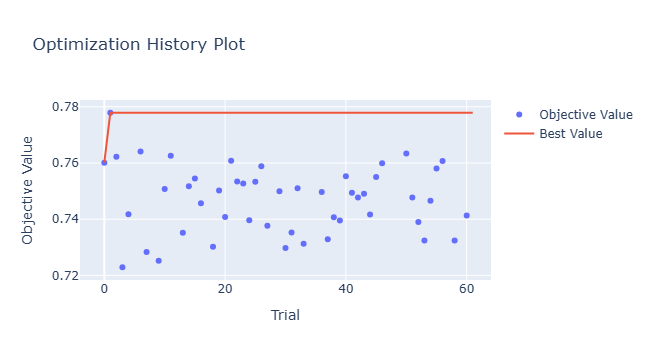

ImportError: Tried to import 'numpy.strings' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'numpy.strings'.

In [172]:
import optuna
import optuna.visualization as vis

# Carica lo studio dal file locale sul server
study = optuna.load_study(
    # study_name='my_cv_optimization_cadmus_02_02_26_HS', 
    # storage='sqlite:///my_study_cadmus_02_02_26_HS.db'
    
    study_name='my_cv_optimization_cadmus_data1_RIPRODUCIBILE_03_02_26',  # Un nome per il tuo studio
    storage='sqlite:///my_study_cadmus_data1_RIPRODUCIBILE_03_02_26.db'
)

# Questi grafici appariranno direttamente dentro Jupyter
vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

In [23]:
study.best_params


{'dropout_rate': 0.47805461769215474,
 'num_heads': 5,
 'batch_size': 64,
 'lr': 1.2764937047792502e-05,
 'weight_decay': 8.322724281704737e-07,
 'patience': 5}

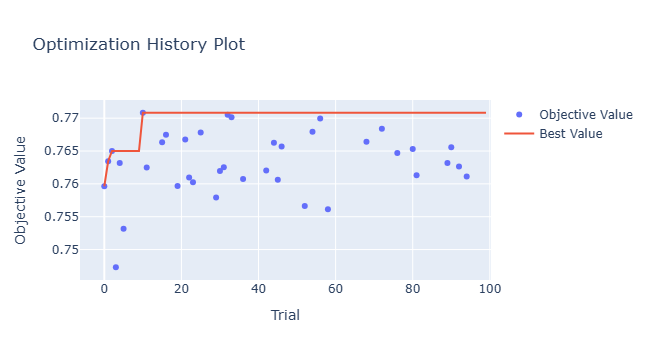

In [21]:
vis.plot_optimization_history(study)

In [9]:
import optuna
import pandas as pd

# 1. Connessione al database
study_name = 'my_cv_optimization_cadmus_15_12_25_HS'
storage_path = 'sqlite:///my_study_cadmus_15_12_25_HS.db'

study = optuna.load_study(study_name=study_name, storage=storage_path)

# 2. Estrazione di tutti i trial in un DataFrame
df = study.trials_dataframe()

# 3. Pulizia opzionale: rinominiamo le colonne per leggerle meglio
# Rimuove i prefissi 'user_attrs_' e 'params_' dai nomi delle colonne
df.columns = [c.replace('user_attrs_', '').replace('params_', '') for c in df.columns]

# 4. Ordinamento per il miglior risultato (MCC)
df = df.sort_values(by="value", ascending=False)

# 5. Salvataggio in vari formati
df.to_csv("estrazione_completa_optuna.csv", index=False)
df.to_excel("estrazione_completa_optuna.xlsx", index=False) # Richiede openpyxl

print(f"Estrazione completata! Totale trial analizzati: {len(df)}")
print("\nPrime 5 righe (Migliori trial):")
df

Estrazione completata! Totale trial analizzati: 2

Prime 5 righe (Migliori trial):


,number,value,datetime_start,datetime_complete,duration,batch_size,dropout_rate,lr,num_heads,patience,...,mean_Sn,mean_Sp,std_ACC,std_AUROC,std_F1,std_MCC,std_PR_AUC,std_Sn,std_Sp,state
1,1,0.763441,2025-12-15 16:08:24.917328,2025-12-15 16:14:23.071247,0 days 00:05:58.153919,32,0.383229,0.000002,5,10,...,0.903652,0.859130,0.004220,0.004087,0.004690,0.008816,0.008876,0.009778,0.003740,COMPLETE
0,0,0.759641,2025-12-15 16:01:37.613368,2025-12-15 16:08:24.907878,0 days 00:06:47.294510,32,0.249816,0.000001,4,11,...,0.903218,0.855217,0.003011,0.004366,0.003749,0.006647,0.007348,0.018642,0.017958,COMPLETE
